In [33]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [34]:
path = "/content/gdrive/MyDrive/machine_learning/pertemuan07"

In [35]:
import pandas as pd
df = pd.read_csv(path + "/praktikum_07/data/apples_and_oranges.csv")
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [36]:
df.describe()

,Weight,Size
count,40.000000,40.000000
mean,70.200000,4.922750
std,3.039906,0.590063
min,65.000000,4.010000
25%,68.000000,4.360000
50%,70.000000,4.930000
75%,73.000000,5.472500
max,75.000000,5.850000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [38]:
df['Class'].unique()

array(['orange', 'apple'], dtype=object)

In [39]:
df['Class'].value_counts()

,count
Class,
orange,20
apple,20


In [40]:
X = df[['Size', 'Weight']]

y = df['Class']

In [41]:
X.head()

,Size,Weight
0,4.39,69
1,4.21,69
2,4.09,65
3,5.85,72
4,4.70,67


In [42]:
y.head()

,Class
0,orange
1,orange
2,orange
3,apple
4,orange


In [43]:
import numpy as np
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

print(f"Jumlah data train: {len(X_train)}")
print(f"Jumlah data test: {len(X_test)}")

Jumlah data train: 32
Jumlah data test: 8


In [44]:
from sklearn.svm import SVC
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
#akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
#laporan klasifikasi
print(f"\nLaporan Klasifikasi:\n{classification_report(y_test, y_pred)}")

Akurasi: 100.00%

Laporan Klasifikasi:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8




Confusion Matrix:
 [[3 0]
 [0 5]]


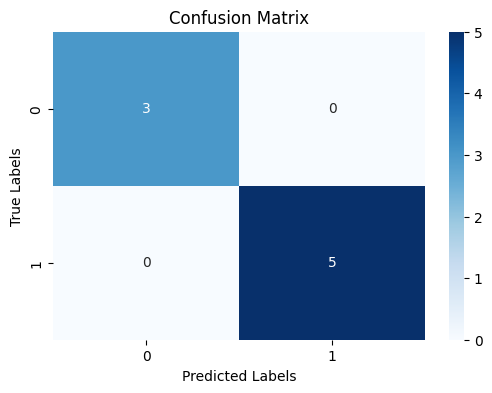

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Jika kamu tahu nama kelas (opsional, agar lebih informatif)
#misalnya: class_names = ['Negatif', 'Positif']
# maka tambahkan ke heatmap di bagian "xticklabels" dan "yticklabels"
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

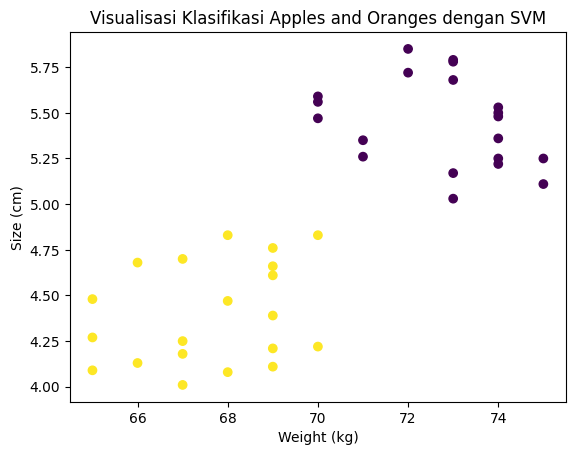

In [47]:
import matplotlib.pyplot as plt
plt.scatter(df['Weight'], df['Size'], c=df['Class'].astype('category').cat.codes)
plt.xlabel('Weight (kg)')
plt.ylabel('Size (cm)')
plt.title('Visualisasi Klasifikasi Apples and Oranges dengan SVM')
plt.show()

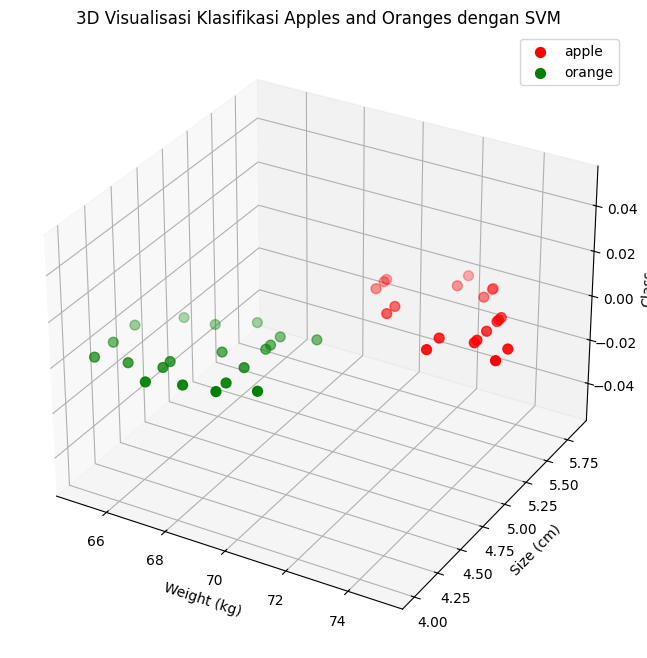

In [48]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
#3. Encode label (ubah teks jadi angka)
le=LabelEncoder()
df['ClassEncoded'] = le.fit_transform(df['Class'])
#8. Plot 3D hasil klasifikasi
fig=plt.figure(figsize=(10, 8))
ax=fig.add_subplot(111, projection='3d')
# Warna untuk tiap kelas
colors = ['r', 'g', 'b']
labels = le.classes_
# Plot tiap spesies dengan warna berbeda for i, species in enumerate (labels):
for i, species in enumerate(labels):
  subset = df[df['ClassEncoded'] == i]
  ax.scatter(
              subset['Weight'],
              subset['Size'],
              color=colors[i],
              label=species,
              s = 50
            )
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Size (cm)')
ax.set_zlabel('Class')
ax.set_title('3D Visualisasi Klasifikasi Apples and Oranges dengan SVM')
ax.legend()
plt.show()